### HOG + SVM Classification

Classical machine learning baseline is implemented using Histogram of Oriented Gradients (HOG) features and a SVM classifier.

1. Raw MRI images
2. Global Histogram Equalization (GHE)
3. CLAHE-enhanced MRI images
evaluated

* Comparison between a deep learning model and a traditional feature-based classification approach

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
PROJECT_DIR = Path.cwd().parent

OUTPUT_DIR = PROJECT_DIR / "outputs"
PROCESSED_DIR = OUTPUT_DIR / "processed"

RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Processed directory exists:", PROCESSED_DIR.exists())

Project directory: C:\Users\elifn\DSAI 583\PROJECT
Processed data directory: C:\Users\elifn\DSAI 583\PROJECT\outputs\processed
Processed directory exists: True


In [3]:
methods = ["raw", "ghe", "clahe"]

datasets = {}

for method in methods:
    file_path = PROCESSED_DIR / f"{method}_data.npz"
    
    data = np.load(file_path)
    
    datasets[method] = {
        "X_train": data["X_train"],
        "y_train": data["y_train"],
        "X_val": data["X_val"],
        "y_val": data["y_val"],
        "X_test": data["X_test"],
        "y_test": data["y_test"]
    }
    
    print(f"{method.upper()} dataset loaded")
    print("X_train:", datasets[method]["X_train"].shape)
    print("X_val:", datasets[method]["X_val"].shape)
    print("X_test:", datasets[method]["X_test"].shape)
    print()

RAW dataset loaded
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)

GHE dataset loaded
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)

CLAHE dataset loaded
X_train: (177, 128, 128, 1)
X_val: (38, 128, 128, 1)
X_test: (38, 128, 128, 1)



In [4]:
def extract_hog_features(X):
    """
    Extracts HOG features from a set of grayscale images.

    Input shape:
    X: (samples, 128, 128, 1)

    Output shape:
    features: (samples, number_of_hog_features)
    """
    features = []
    
    for image in X:
        # Remove channel dimension: (128, 128, 1) -> (128, 128)
        image_2d = image.squeeze()
        
        hog_feature = hog(
            image_2d,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            visualize=False,
            feature_vector=True
        )
        
        features.append(hog_feature)
    
    return np.array(features)

In [5]:
X_train_raw = datasets["raw"]["X_train"]

X_train_raw_hog = extract_hog_features(X_train_raw)

print("Original image data shape:", X_train_raw.shape)
print("HOG feature data shape:", X_train_raw_hog.shape)

Original image data shape: (177, 128, 128, 1)
HOG feature data shape: (177, 8100)


In [6]:
def calculate_metrics(y_true, y_prob):
    """
    Calculates classification metrics for binary classification.
    """
    y_pred = (y_prob >= 0.5).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }
    
    return metrics, y_pred

In [7]:
def plot_confusion_matrix_result(y_true, y_pred, method):
    """
    Plots and saves the confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Tumor", "Tumor"]
    )
    
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"HOG + SVM Confusion Matrix - {method.upper()}")
    plt.savefig(FIGURES_DIR / f"hog_svm_{method}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

In [8]:
def plot_roc_curve_result(y_true, y_prob, method):
    """
    Plots and saves the ROC curve.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax)
    plt.title(f"HOG + SVM ROC Curve - {method.upper()}")
    plt.grid(True)
    plt.savefig(FIGURES_DIR / f"hog_svm_{method}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
def train_and_evaluate_hog_svm(method):
    print("=" * 60)
    print(f"Training HOG + SVM on {method.upper()} images")
    print("=" * 60)
    
    X_train = datasets[method]["X_train"]
    y_train = datasets[method]["y_train"]
    X_test = datasets[method]["X_test"]
    y_test = datasets[method]["y_test"]
    
    print("Extracting HOG features...")
    X_train_hog = extract_hog_features(X_train)
    X_test_hog = extract_hog_features(X_test)
    
    print("X_train_hog:", X_train_hog.shape)
    print("X_test_hog:", X_test_hog.shape)
    
    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    svm_model.fit(X_train_hog, y_train)
    
    y_prob = svm_model.predict_proba(X_test_hog)[:, 1]
    
    metrics, y_pred = calculate_metrics(y_test, y_prob)
    
    print("\nTest metrics:")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")
    
    plot_confusion_matrix_result(y_test, y_pred, method)
    plot_roc_curve_result(y_test, y_prob, method)
    
    result = {
        "model": "HOG + SVM",
        "preprocessing": method,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics["roc_auc"]
    }
    
    return result, svm_model

Training HOG + SVM on RAW images
Extracting HOG features...
X_train_hog: (177, 8100)
X_test_hog: (38, 8100)

Test metrics:
accuracy: 0.8158
precision: 0.7857
recall: 0.9565
f1_score: 0.8627
roc_auc: 0.8638


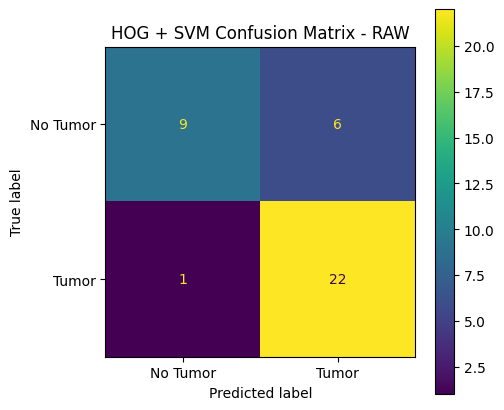

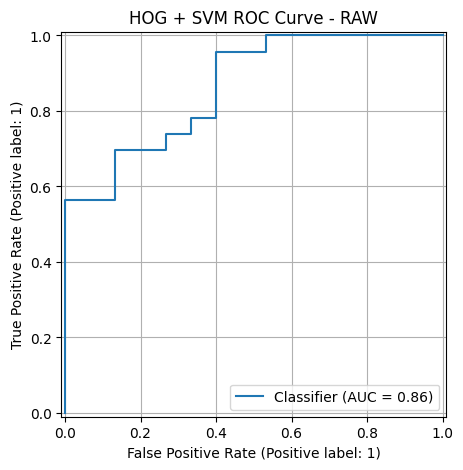

Training HOG + SVM on GHE images
Extracting HOG features...
X_train_hog: (177, 8100)
X_test_hog: (38, 8100)

Test metrics:
accuracy: 0.8158
precision: 0.7857
recall: 0.9565
f1_score: 0.8627
roc_auc: 0.8551


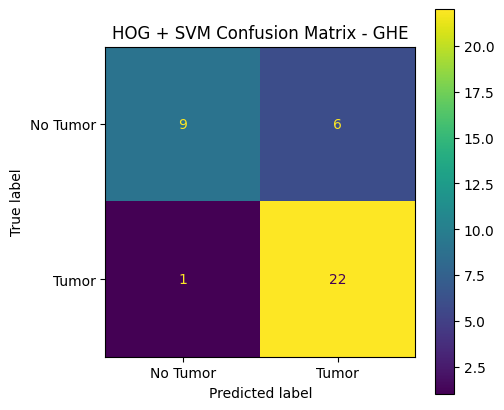

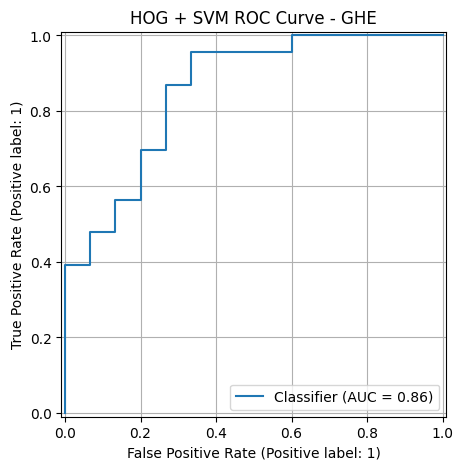

Training HOG + SVM on CLAHE images
Extracting HOG features...
X_train_hog: (177, 8100)
X_test_hog: (38, 8100)

Test metrics:
accuracy: 0.8158
precision: 0.7857
recall: 0.9565
f1_score: 0.8627
roc_auc: 0.8667


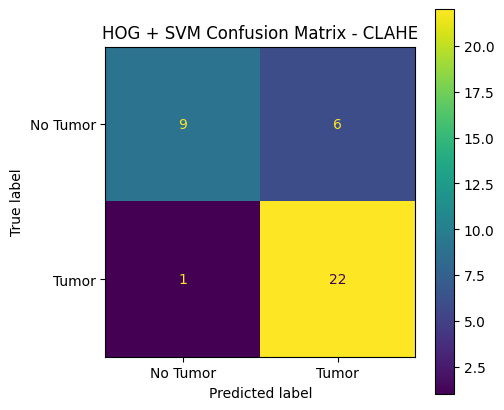

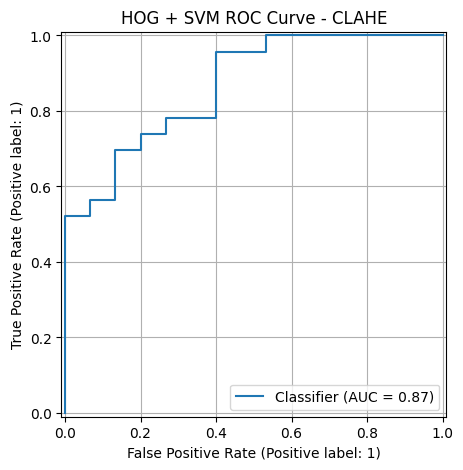

In [10]:
hog_svm_results = {}
hog_svm_models = {}

for method in methods:
    result, model = train_and_evaluate_hog_svm(method)
    
    hog_svm_results[method] = result
    hog_svm_models[method] = model

In [11]:
hog_svm_results_df = pd.DataFrame(hog_svm_results.values())

display(hog_svm_results_df)

,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
0,HOG + SVM,raw,0.815789,0.785714,0.956522,0.862745,0.863768
1,HOG + SVM,ghe,0.815789,0.785714,0.956522,0.862745,0.855072
2,HOG + SVM,clahe,0.815789,0.785714,0.956522,0.862745,0.866667


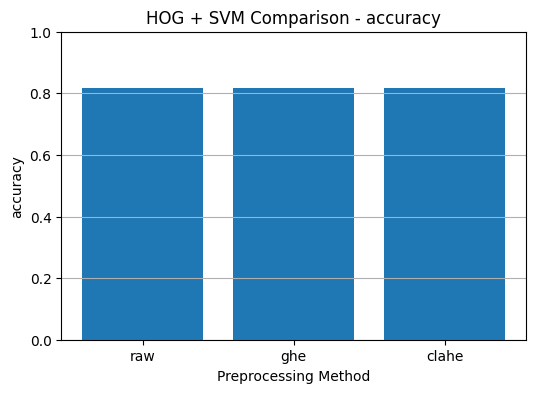

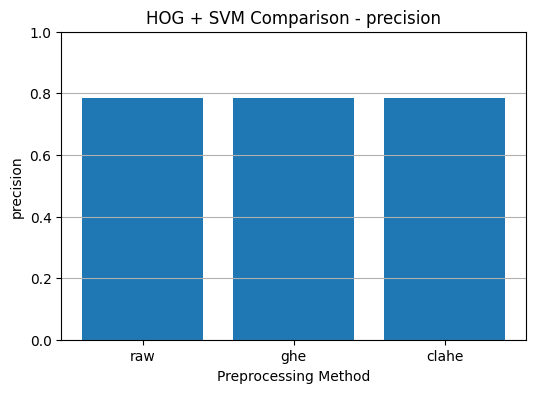

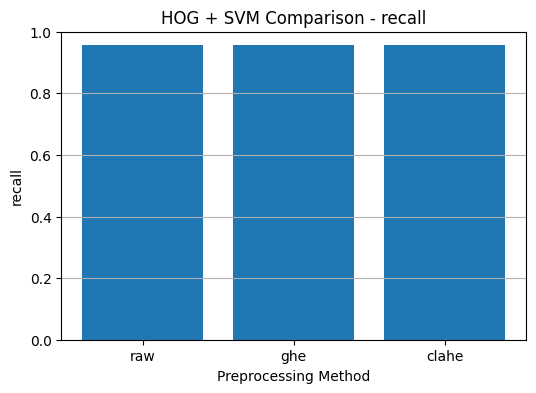

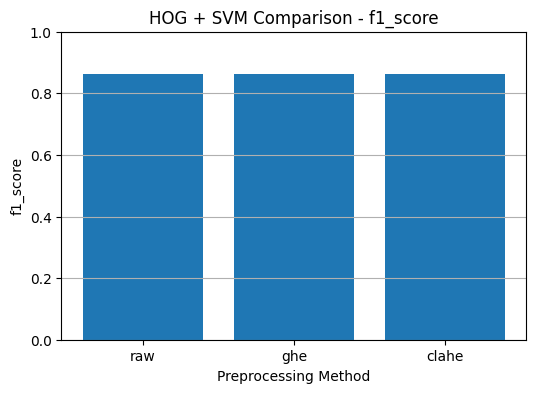

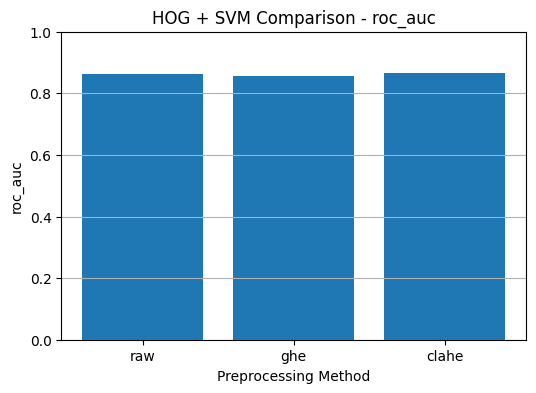

In [12]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(hog_svm_results_df["preprocessing"], hog_svm_results_df[metric])
    plt.title(f"HOG + SVM Comparison - {metric}")
    plt.xlabel("Preprocessing Method")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.savefig(FIGURES_DIR / f"hog_svm_comparison_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
hog_svm_results_df.to_csv(RESULTS_DIR / "hog_svm_results.csv", index=False)

In [17]:
best_hog_svm_method = hog_svm_results_df.sort_values(
    by=["f1_score", "roc_auc"],
    ascending=False
).iloc[0]

print("Best HOG + SVM preprocessing method based on F1-score and ROC-AUC:")
print(best_hog_svm_method)

Best HOG + SVM preprocessing method based on F1-score and ROC-AUC:
model            HOG + SVM
preprocessing        clahe
accuracy          0.815789
precision         0.785714
recall            0.956522
f1_score          0.862745
roc_auc           0.866667
Name: 2, dtype: object


In [15]:
cnn_results_path = RESULTS_DIR / "cnn_results.csv"

if cnn_results_path.exists():
    cnn_results_df = pd.read_csv(cnn_results_path)
    
    combined_results_df = pd.concat(
        [cnn_results_df, hog_svm_results_df],
        ignore_index=True
    )
    
    display(combined_results_df)
    
    combined_results_df.to_csv(RESULTS_DIR / "combined_model_results.csv", index=False)
else:
    print("CNN results file not found. Run Notebook 03 first.")

,model,preprocessing,accuracy,precision,recall,f1_score,roc_auc
0,CNN,raw,0.710526,0.772727,0.739130,0.755556,0.675362
1,CNN,ghe,0.605263,0.750000,0.521739,0.615385,0.713043
2,CNN,clahe,0.631579,0.714286,0.652174,0.681818,0.666667
3,HOG + SVM,raw,0.815789,0.785714,0.956522,0.862745,0.863768
4,HOG + SVM,ghe,0.815789,0.785714,0.956522,0.862745,0.855072
5,HOG + SVM,clahe,0.815789,0.785714,0.956522,0.862745,0.866667


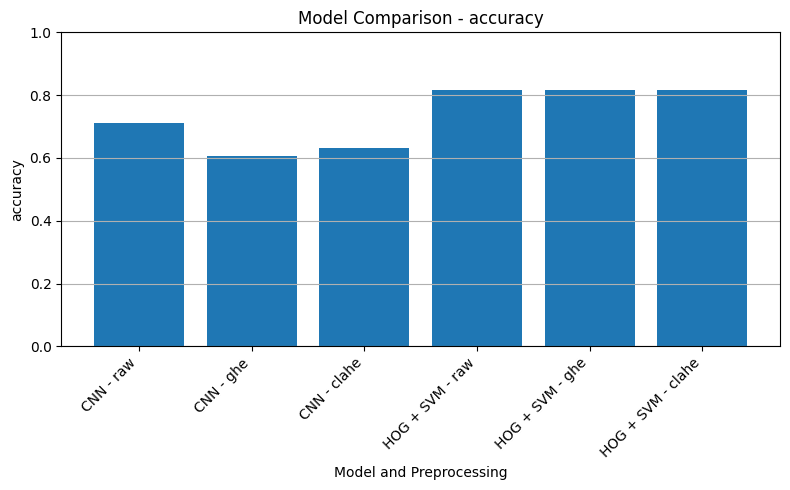

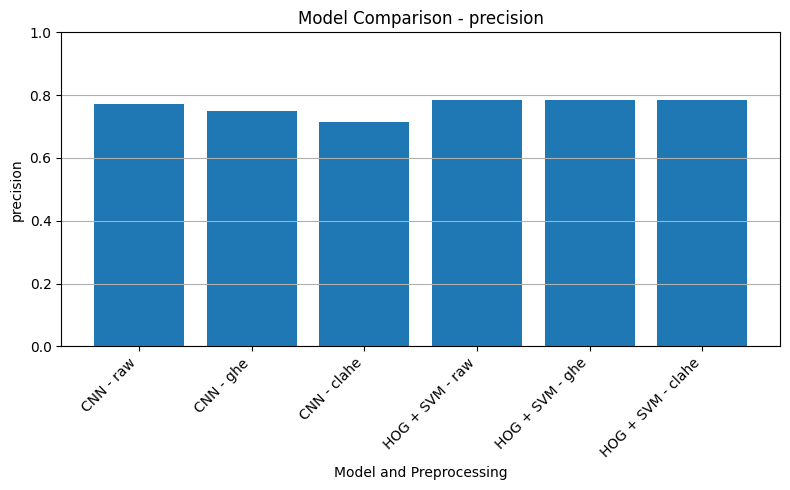

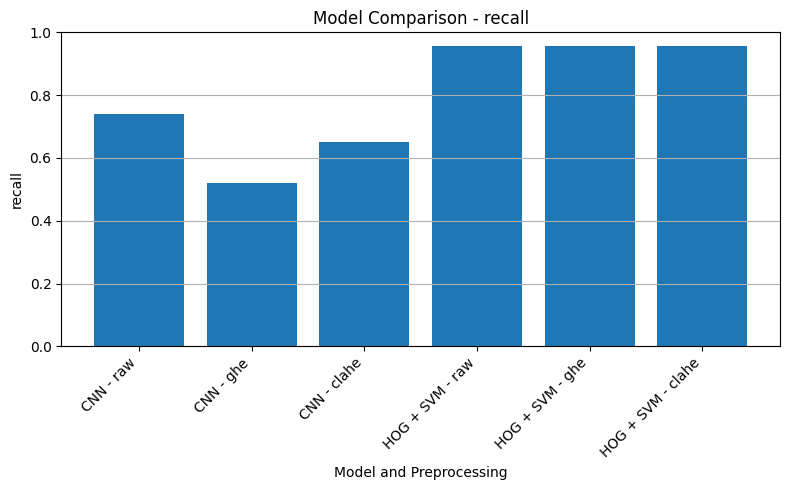

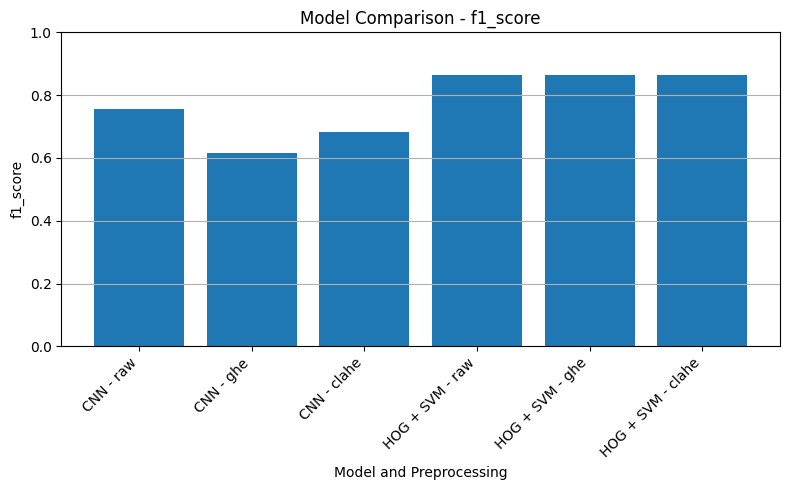

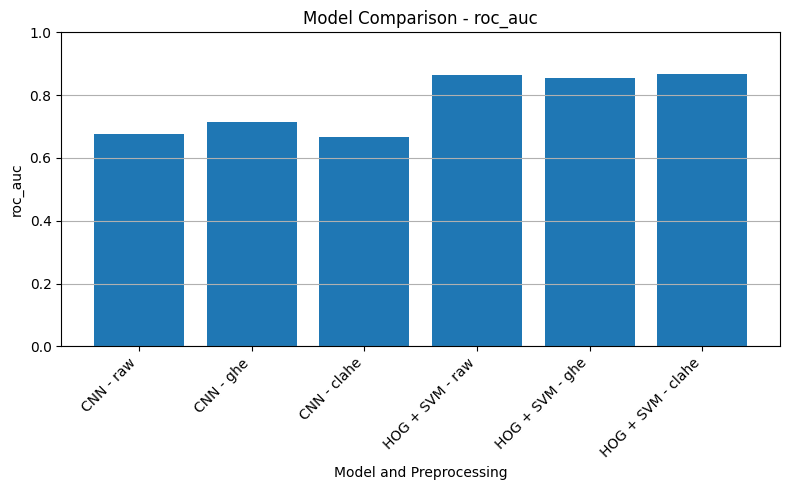

In [16]:
if "combined_results_df" in globals():
    for metric in metrics_to_plot:
        plt.figure(figsize=(8, 5))
        
        labels = (
            combined_results_df["model"] + " - " +
            combined_results_df["preprocessing"]
        )
        
        plt.bar(labels, combined_results_df[metric])
        plt.title(f"Model Comparison - {metric}")
        plt.xlabel("Model and Preprocessing")
        plt.ylabel(metric)
        plt.ylim(0, 1)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"combined_comparison_{metric}.png", dpi=300, bbox_inches="tight")
        plt.show()

Training HOG + SVM on RAW images
Extracting HOG features...
X_train_hog: (177, 8100)
X_test_hog: (38, 8100)

Test metrics:
accuracy: 0.8158
precision: 0.7857
recall: 0.9565
f1_score: 0.8627
roc_auc: 0.8638


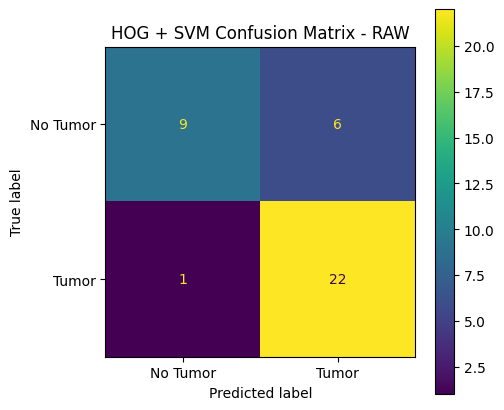

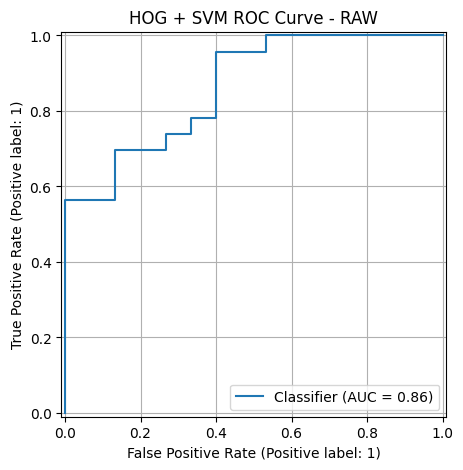

Training HOG + SVM on GHE images
Extracting HOG features...
X_train_hog: (177, 8100)
X_test_hog: (38, 8100)

Test metrics:
accuracy: 0.8158
precision: 0.7857
recall: 0.9565
f1_score: 0.8627
roc_auc: 0.8551


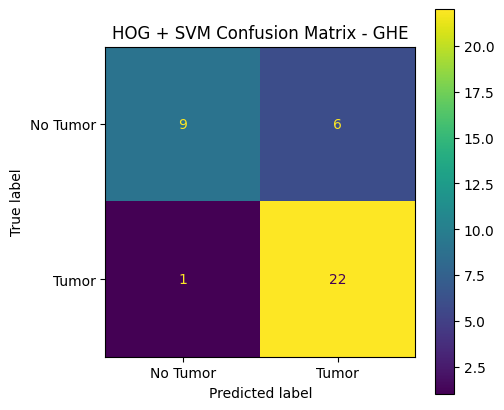

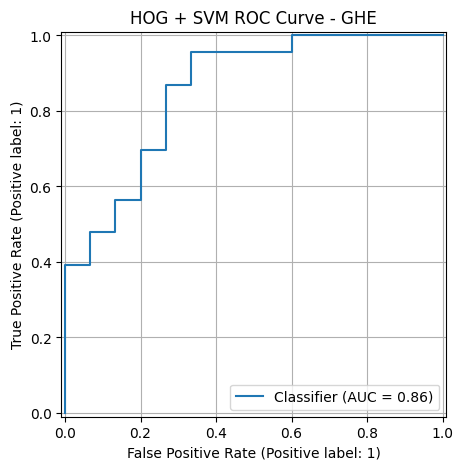

Training HOG + SVM on CLAHE images
Extracting HOG features...
X_train_hog: (177, 8100)
X_test_hog: (38, 8100)

Test metrics:
accuracy: 0.8158
precision: 0.7857
recall: 0.9565
f1_score: 0.8627
roc_auc: 0.8667


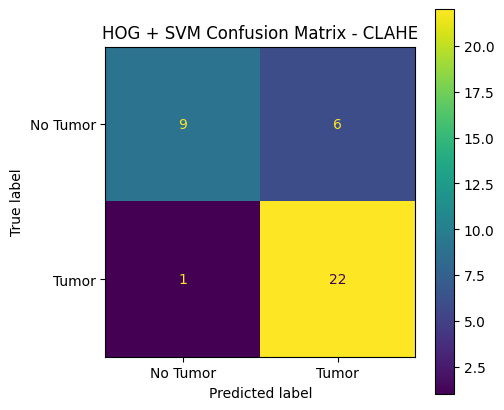

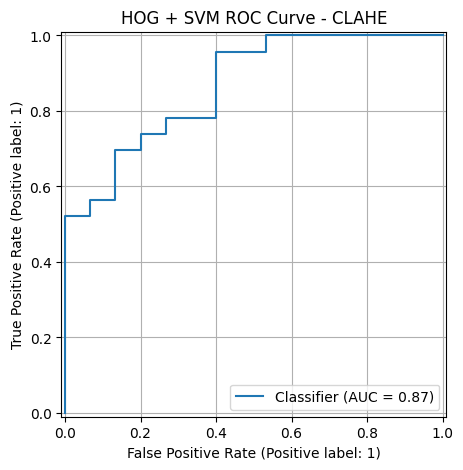

In [18]:
import joblib
for method in methods:
    result, model = train_and_evaluate_hog_svm(method)
    
    hog_svm_results[method] = result
    hog_svm_models[method] = model
    
    joblib.dump(model, MODELS_DIR / f"hog_svm_{method}.joblib")